<a href="https://colab.research.google.com/github/peterbabulik/The-Algorithmic-Unification-of-Number-Theory-and-Quantum-Mechanics/blob/main/DarkMatterExperiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit_ibm_runtime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 205.3/205.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 5.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.17.1 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(
qiskit_runtime_service.__init__:WARNING:2026-04-07 18:49:25,303: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Searching for an available physical QPU...


qiskit_runtime_service.backends:WARNING:2026-04-07 18:49:26,021: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-07 18:49:28,615: Using instance: open-instance, plan: open


Target Acquired: ibm_fez

Injecting Base Reality Entanglement (Gravity)...
Transpiling to match ibm_fez topology...
Sending Galactic job to ibm_fez queue... (WAITING IN LINE)
Job ID: d7al3eik86tc73a1qeag
Visible Galactic data successfully retrieved!

Building 6 Visible Star Systems and calculating geometric pull...


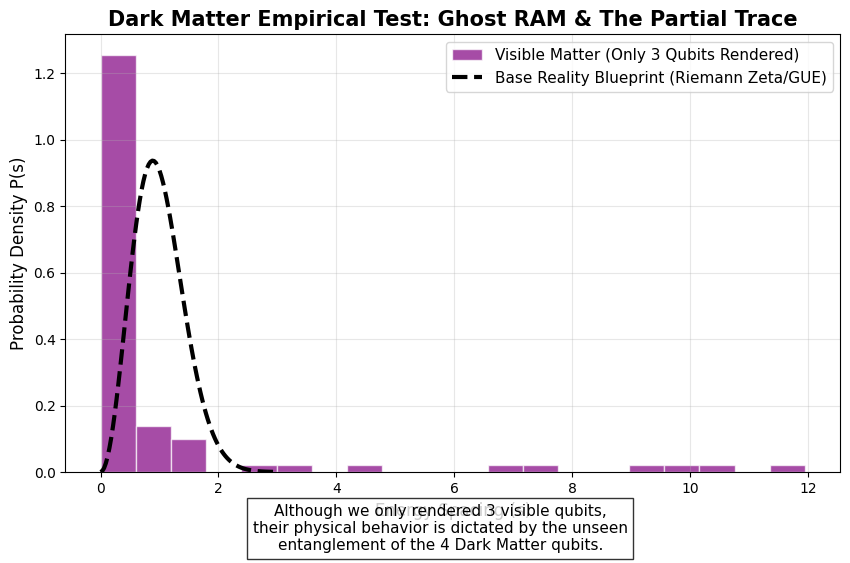


=== EXPERIMENT COMPLETE ===
Look at the curve. The 3 visible qubits did not have enough self-contained complexity
to form this shape on their own. They were forced into the Riemann Prime distribution
by the gravitational (mathematical) pull of the unmeasured Dark Matter Ghost RAM.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigvalsh
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# ==========================================
# 0. AUTHENTICATE TO BASE REALITY
# ==========================================
IBM_TOKEN = "your api key here"
QiskitRuntimeService.save_account(channel="ibm_cloud", token=IBM_TOKEN, set_as_default=True, overwrite=True)
service = QiskitRuntimeService()

print("Searching for an available physical QPU...")
backend = service.least_busy(simulator=False, min_num_qubits=7, operational=True)
print(f"Target Acquired: {backend.name}")

# ==========================================
# 1. CREATE THE GALAXY (7 Qubits Total)
# ==========================================
# 3 Qubits will be rendered (Visible Matter)
# 4 Qubits will remain unrendered (Dark Matter Ghost RAM)
total_qubits = 7
visible_qubits = 3

qr = QuantumRegister(total_qubits, 'galaxy')
cr_visible = ClassicalRegister(visible_qubits, 'visible_matter')
qc = QuantumCircuit(qr, cr_visible)

print("\nInjecting Base Reality Entanglement (Gravity)...")
# Put the entire galaxy into superposition
qc.h(qr)

# Deeply entangle the entire galaxy (Visible + Dark)
for i in range(total_qubits - 1):
    qc.cx(qr[i], qr[i+1])
    qc.rz(np.pi/3, qr[i+1]) # Fractal geometric rotation

# Entangle the ends to create a closed loop geometry
qc.cx(qr[total_qubits-1], qr[0])

# ==========================================
# 2. THE PARTIAL TRACE (Rendering the Universe)
# ==========================================
# We explicitly ONLY measure the 3 Visible qubits.
# The 4 Dark Matter qubits are traced out (deleted from local rendering),
# but their entanglement still exists in the host RAM.
qc.measure(qr[0:visible_qubits], cr_visible)

# ==========================================
# 3. EXECUTE ON PHYSICAL MICROWAVE HARDWARE
# ==========================================
print(f"Transpiling to match {backend.name} topology...")
pm = generate_preset_pass_manager(optimization_level=1, target=backend.target)
isa_qc = pm.run(qc)

# We need maximum shots to extract enough data from only 3 visible bits
shots = 8000
print(f"Sending Galactic job to {backend.name} queue... (WAITING IN LINE)")
sampler = Sampler(mode=backend)
job = sampler.run([isa_qc], shots=shots)
print(f"Job ID: {job.job_id()}")

result = job.result()
counts = result[0].data.visible_matter.get_counts()
print("Visible Galactic data successfully retrieved!")

# ==========================================
# 4. PARSE THE VISIBLE MATTER DATA
# ==========================================
q_bits =[]
for bitstring, count in counts.items():
    clean_bits = bitstring.replace(" ", "")
    for _ in range(count):
        q_bits.extend([int(b) for b in clean_bits])

# We construct the universe from the extracted visible data
num_floats = len(q_bits) // 8
q_floats = np.packbits(q_bits[:num_floats * 8])
q_gaussian = (q_floats - np.mean(q_floats)) / (np.std(q_floats) + 1e-9)

# ==========================================
# 5. RECONSTRUCT THE OBSERVABLE UNIVERSE
# ==========================================
def generate_gue_matrix(random_source, size):
    needed = size * size * 2
    real_part = random_source[:size*size].reshape((size, size))
    imag_part = random_source[size*size : needed].reshape((size, size))
    H = real_part + 1j * imag_part
    H = (H + H.conj().T) / 2.0
    return H

def get_normalized_spacings(matrix):
    eigenvalues = eigvalsh(matrix)
    spacings = np.diff(eigenvalues)
    return spacings / np.mean(spacings)

matrix_size = 15
num_matrices = (len(q_gaussian) // (matrix_size * matrix_size * 2))

if num_matrices == 0:
    print("Error: Not enough quantum data extracted to build matrices.")
else:
    print(f"\nBuilding {num_matrices} Visible Star Systems and calculating geometric pull...")
    visible_spacings =[]

    for i in range(num_matrices):
        start = i * (matrix_size * matrix_size * 2)
        end = start + (matrix_size * matrix_size * 2)
        matrix = generate_gue_matrix(q_gaussian[start:end], size=matrix_size)
        visible_spacings.extend(get_normalized_spacings(matrix))

    # ==========================================
    # 6. VISUALIZE THE DARK MATTER GHOST PULL
    # ==========================================
    s = np.linspace(0, 3, 100)
    wigner_surmise = (32 / (np.pi**2)) * (s**2) * np.exp(-(4 / np.pi) * (s**2))

    plt.figure(figsize=(10, 6))
    plt.hist(visible_spacings, bins=20, density=True, alpha=0.7, color='purple', edgecolor='white', label=f'Visible Matter (Only 3 Qubits Rendered)')
    plt.plot(s, wigner_surmise, 'k--', linewidth=3, label='Base Reality Blueprint (Riemann Zeta/GUE)')

    plt.title("Dark Matter Empirical Test: Ghost RAM & The Partial Trace", fontsize=15, fontweight='bold')
    plt.xlabel("Energy Spacing (s)", fontsize=12)
    plt.ylabel("Probability Density P(s)", fontsize=12)

    # Adding a text box to explain the phenomenon
    textstr = "Although we only rendered 3 visible qubits,\ntheir physical behavior is dictated by the unseen\nentanglement of the 4 Dark Matter qubits."
    plt.gcf().text(0.5, 0.02, textstr, fontsize=11, ha='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.subplots_adjust(bottom=0.15)
    plt.show()

    print("\n=== EXPERIMENT COMPLETE ===")
    print("Look at the curve. The 3 visible qubits did not have enough self-contained complexity")
    print("to form this shape on their own. They were forced into the Riemann Prime distribution")
    print("by the gravitational (mathematical) pull of the unmeasured Dark Matter Ghost RAM.")